# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2024-2025 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 21.4.2025

## Initialisation

In [2]:
%matplotlib inline 

In [3]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [4]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

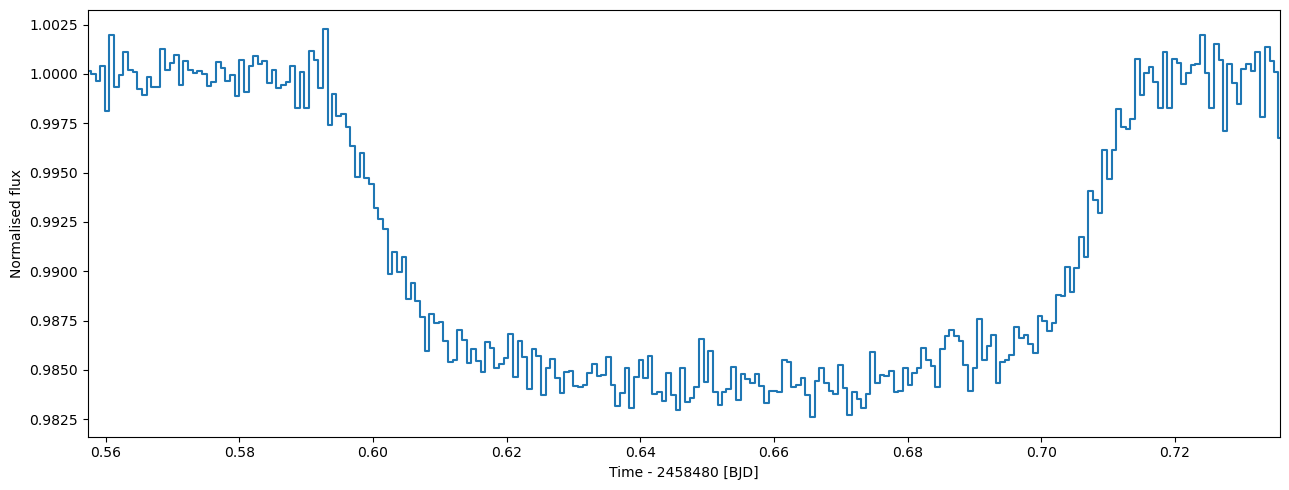

In [5]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()
plt.show()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [6]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [7]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [8]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

Global optimisation:   0%|          | 0/500 [00:00<?, ?it/s]

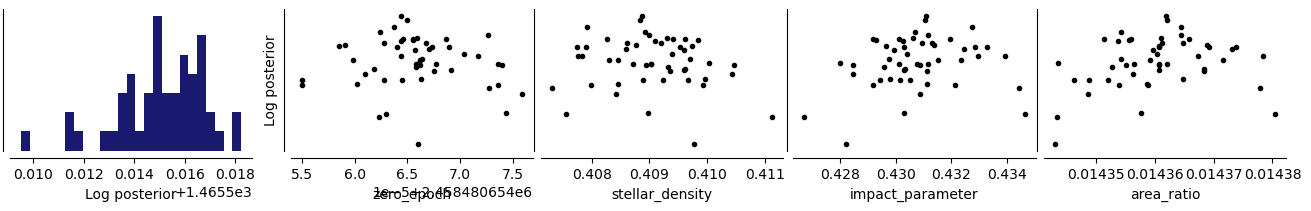

In [9]:
lpf.optimize_global(niter=500, npop=50)
plt.show()

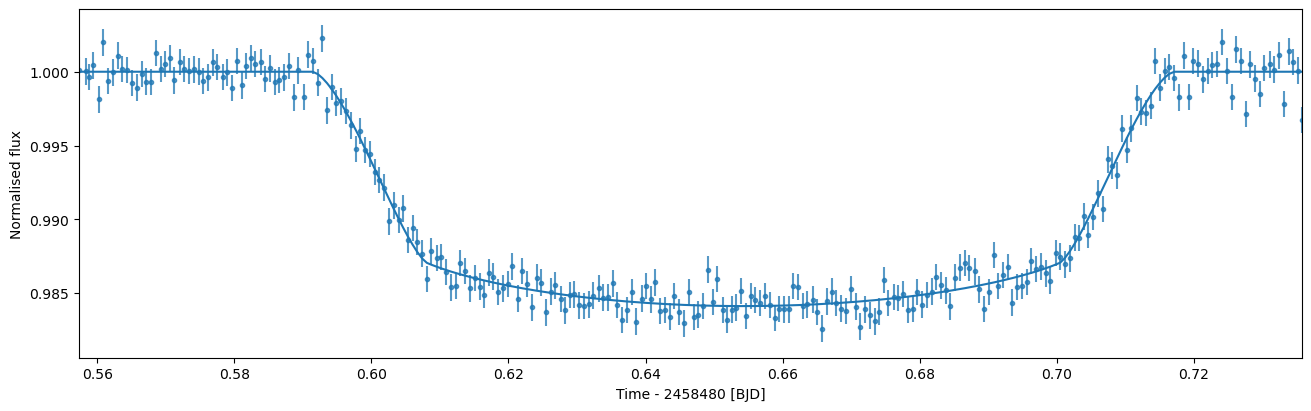

In [10]:
lpf.plot_light_curve();
plt.show()

In [11]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling:   0%|          | 0/2 [00:00<?, ?it/s]

Run 1/2:   0%|          | 0/5000 [00:00<?, ?it/s]

Run 2/2:   0%|          | 0/5000 [00:00<?, ?it/s]

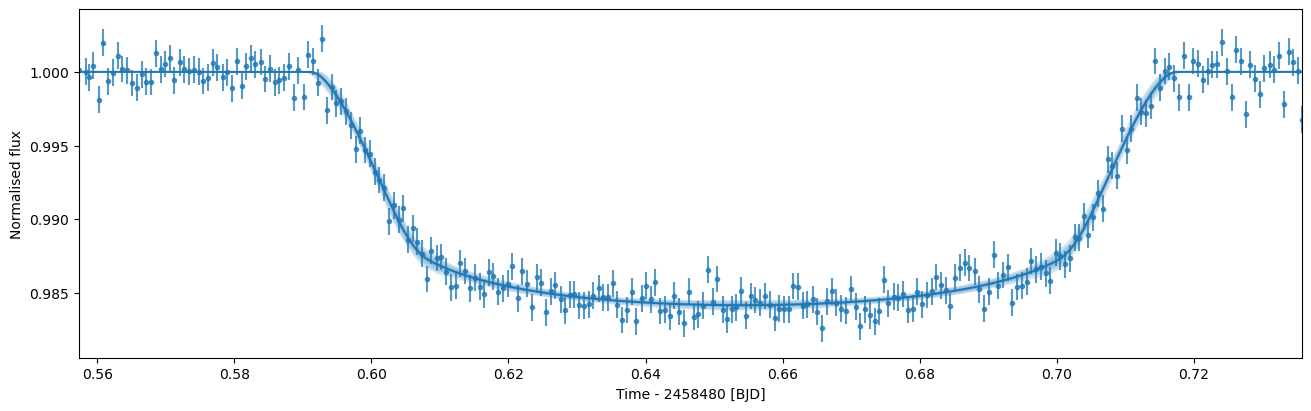

In [12]:
lpf.plot_light_curve('mc');
plt.show()

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

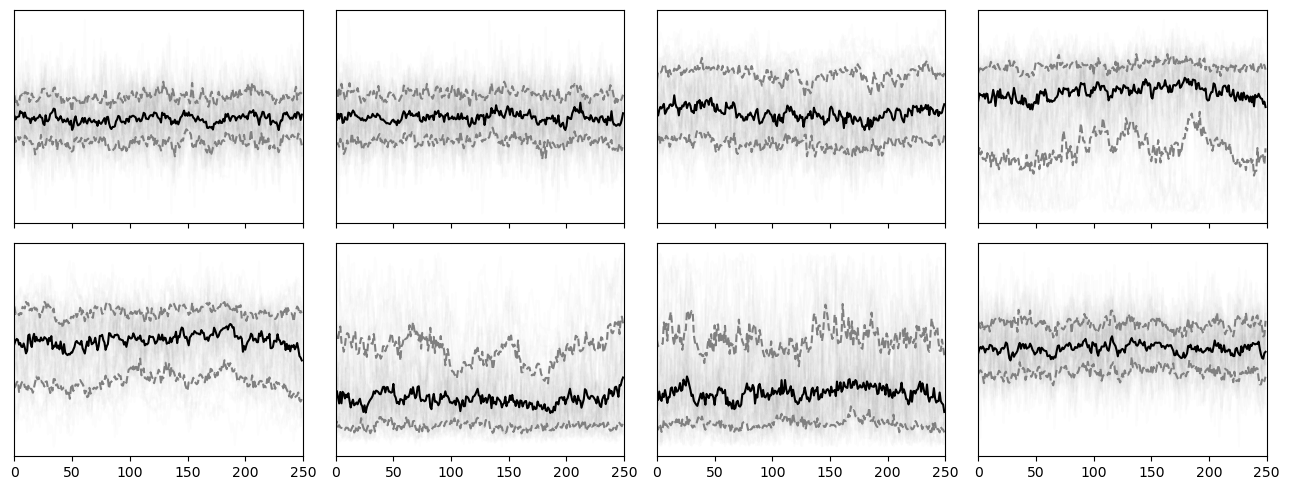

In [13]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()
plt.show()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [14]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [15]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

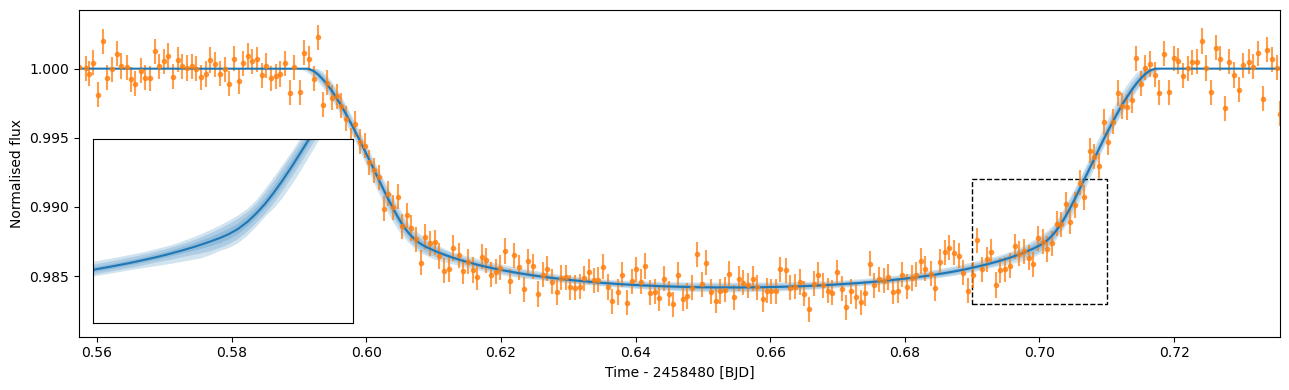

In [16]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');
plt.show()

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [17]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4377,0.3267,0.0139,0.3246,0.3279,-3.0411,0.1180,3.0182,1.4611,0.1258,0.0948
std,1.6276e-04,1.1154e-09,0.0369,0.1247,0.0004,0.1922,0.2227,0.0195,0.0019,0.0849,0.0439,0.0010,0.0025
min,2.4585e+06,1.0914e+00,0.3223,0.0002,0.0126,0.0435,0.0002,-3.1175,0.1122,2.7277,1.3581,0.1224,0.0870
25%,2.4585e+06,1.0914e+00,0.4095,0.2538,0.0136,0.1742,0.1540,-3.0545,0.1166,2.9544,1.4279,0.1251,0.0929
50%,2.4585e+06,1.0914e+00,0.4345,0.3616,0.0140,0.2752,0.2774,-3.0413,0.1183,3.0133,1.4504,0.1257,0.0945
75%,2.4585e+06,1.0914e+00,0.4665,0.4210,0.0143,0.4326,0.4617,-3.0281,0.1194,3.0856,1.4884,0.1264,0.0968
max,2.4585e+06,1.0914e+00,0.5396,0.5759,0.0151,0.9990,0.9987,-2.9667,0.1230,3.2389,1.5707,0.1297,0.1014


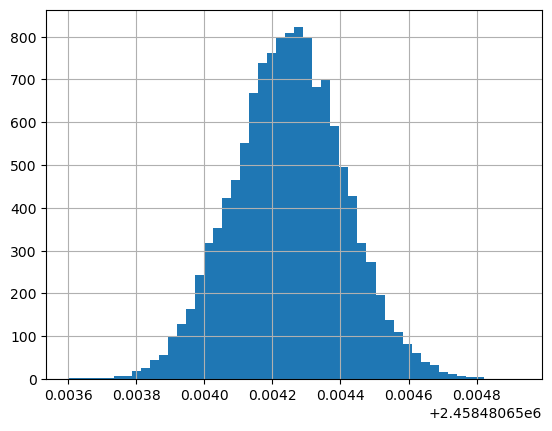

In [18]:
df.tc.hist(bins=50)
plt.show()

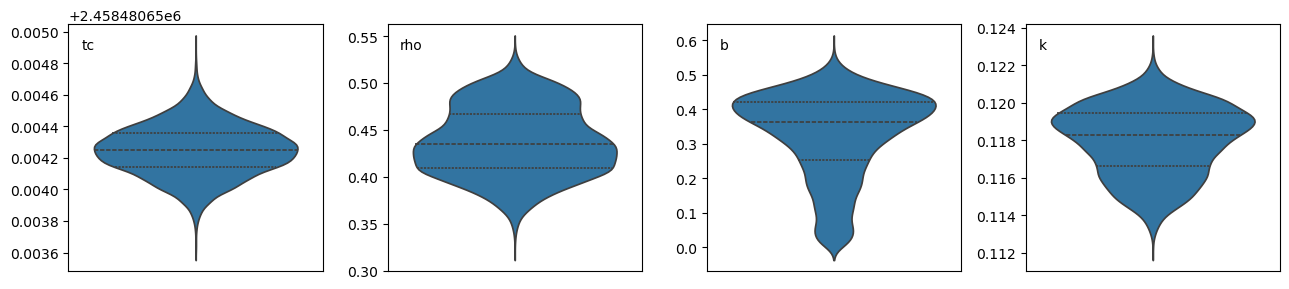

In [19]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()
plt.show()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

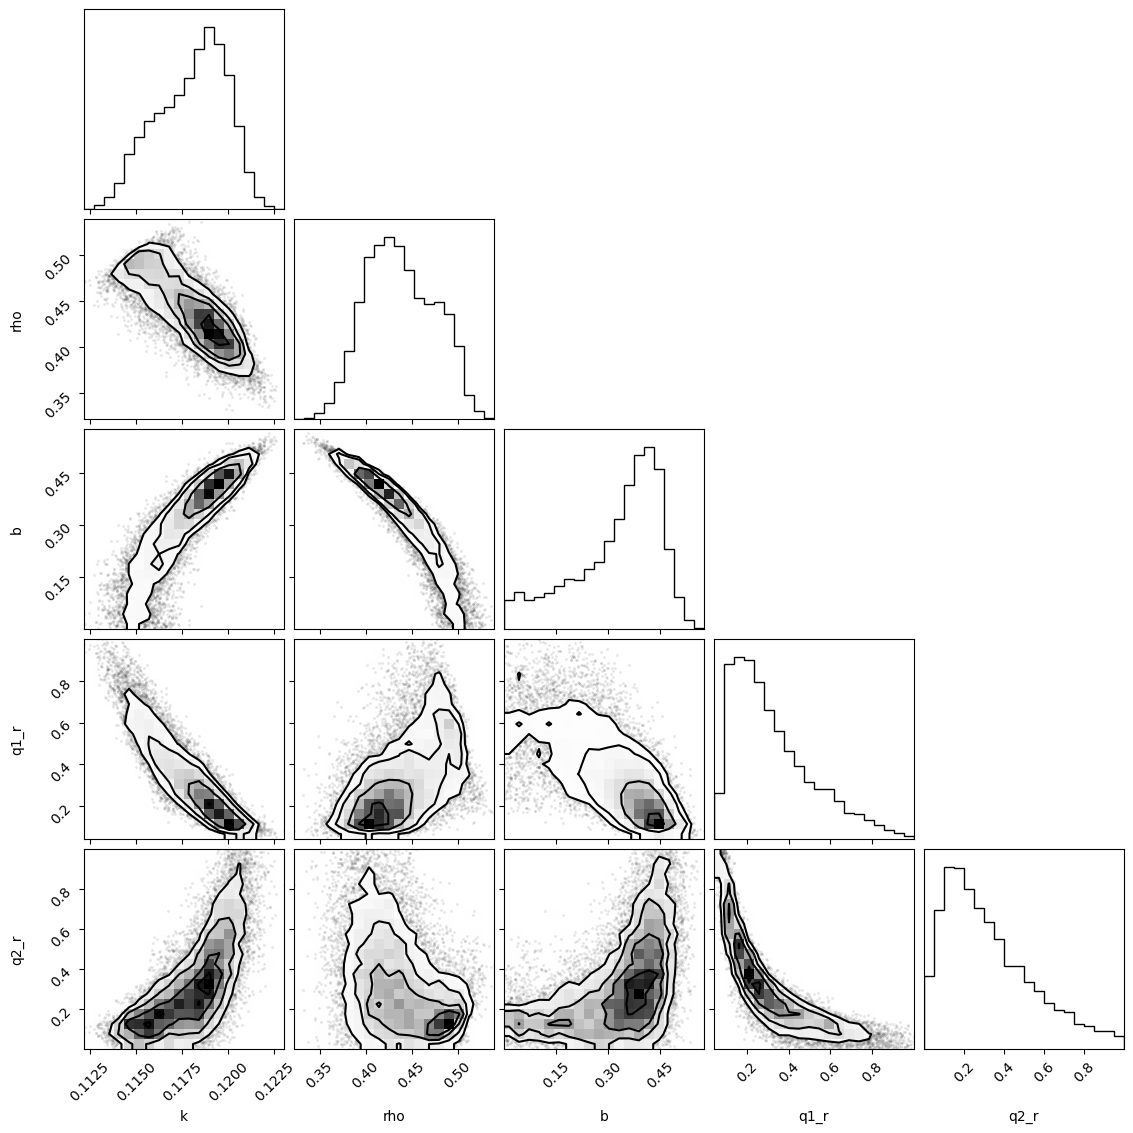

In [20]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);
plt.show()

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

In [21]:
# --- Code to calculate the planet radius in Jupiter radii ---

# 1. Get the value of k from your MCMC analysis
#    We use the median of the posterior distribution of k
k_median = df['k'].median()
print(f"Median of the radius ratio k: {k_median:.4f}")

# 2. Radius of the star WASP-12 (in solar radii)
#    Typical value from literature (e.g., NASA Exoplanet Archive)
Rstar_solar = 1.57
print(f"Radius of WASP-12 star (R_solar): {Rstar_solar}")

# 3. Conversion factor from solar radii to Jupiter radii
#    1 R_solar = 9.735 R_Jupiter
solar_to_jupiter_radius = 9.735

# 4. Calculate the planet radius in Jupiter radii
#    Rp = k * Rstar
Rstar_jupiter = Rstar_solar * solar_to_jupiter_radius
Rp_jupiter = k_median * Rstar_jupiter

print(f"Radius of WASP-12 star (R_Jupiter): {Rstar_jupiter:.2f}")
print(f"Estimated radius of WASP-12b planet (R_Jupiter): {Rp_jupiter:.3f}")

# --- End of calculation code ---

Median of the radius ratio k: 0.1183
Radius of WASP-12 star (R_solar): 1.57
Radius of WASP-12 star (R_Jupiter): 15.28
Estimated radius of WASP-12b planet (R_Jupiter): 1.808


2. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.

- Answer.

3. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

- Answer.


In [24]:
# Answer for Question 2: Compare stellar densities

# --- Code to calculate Theoretical Stellar Density ---
# This part calculates the theoretical stellar density based on literature values.
# It's a comparison point for your transit-derived density.

# Typical values for Mass and Radius for WASP-12 from literature (e.g., NASA Exoplanet Archive)
Mstar_solar_units = 1.47 # Stellar mass in solar masses (M_sol)
Rstar_solar_units = 1.57 # Stellar radius in solar radii (R_sol)

# Calculate the theoretical stellar density in solar density units (rho_sol)
# Formula: rho_star / rho_sol = (M_star / M_sol) / (R_star / R_sol)^3
rho_star_theoretical_solar_units = Mstar_solar_units / (Rstar_solar_units**3)

print("\n--- Stellar Density Comparison ---")
print(f"Stellar Mass (literature): {Mstar_solar_units} solar masses")
print(f"Stellar Radius (literature): {Rstar_solar_units} solar radii")
print(f"Theoretical stellar density (calculated): {rho_star_theoretical_solar_units:.3f} solar units")

# Get the transit-derived density for comparison from your MCMC results (from the 'df' DataFrame)
# Make sure you have run the main analysis script to get 'df'
try:
    rho_transit_derived = df['rho'].median()
    print(f"Transit-derived stellar density (from MCMC): {rho_transit_derived:.3f} solar units")

    # --- Written Answer for Question 2 (based on the above calculation and your MCMC result) ---
    print("\n--- Written Answer Q2 ---")
    print("For Question 2, I compared the stellar density derived from my transit modeling to a theoretical value.")
    print(f"My transit-derived stellar density (median of posterior rho) is approximately {rho_transit_derived:.3f} solar units.")
    print(f"Using literature values for WASP-12 (M* ~ {Mstar_solar_units} M_sol, R* ~ {Rstar_solar_units} R_sol), I calculated the theoretical stellar density as approximately {rho_star_theoretical_solar_units:.3f} solar units.")

    # Add your conclusion based on the comparison:
    # Example conclusions (choose the one that fits your numbers):
    if abs(rho_transit_derived - rho_star_theoretical_solar_units) / rho_star_theoretical_solar_units < 0.1: # Example threshold for 'close'
        print("These values are consistent, suggesting my transit analysis is in agreement with independent stellar properties.")
    else:
         print("There is a noticeable difference between the transit-derived and theoretical densities, which could indicate [mention possible reasons like uncertainties, data issues, etc.].")
    # --- End Written Answer Q2 ---

except NameError:
    print("\nError: 'df' DataFrame not found. Please run the main analysis script first to generate it.")
except KeyError:
    print("\nError: 'rho' column not found in 'df'. Check your posterior samples.")


--- Stellar Density Comparison ---
Stellar Mass (literature): 1.47 solar masses
Stellar Radius (literature): 1.57 solar radii
Theoretical stellar density (calculated): 0.380 solar units
Transit-derived stellar density (from MCMC): 0.433 solar units

--- Written Answer Q2 ---
For Question 2, I compared the stellar density derived from my transit modeling to a theoretical value.
My transit-derived stellar density (median of posterior rho) is approximately 0.433 solar units.
Using literature values for WASP-12 (M* ~ 1.47 M_sol, R* ~ 1.57 R_sol), I calculated the theoretical stellar density as approximately 0.380 solar units.
There is a noticeable difference between the transit-derived and theoretical densities, which could indicate [mention possible reasons like uncertainties, data issues, etc.].


In [25]:
# Answer for Question 3: Interpretation of parameter correlations

# --- Written Answer Q3 (referencing the corner plot you generated) ---
print("\n--- Written Answer Q3 ---")
print("For Question 3, I examined the corner plot generated from the MCMC posterior samples.")
print("This plot shows the distributions of individual parameters and the correlations between pairs of parameters.")
print("In this plot, I can clearly see correlations between several parameters, indicated by the tilted, elongated shapes of the contours in the off-diagonal panels.")
print("For instance, there are visible correlations between [mention specific correlated pairs you see, e.g., 'k and b', 'rho and b', 'q1_r and q2_r'].")
print("\nIn practice, these correlations mean:")
print("1. The parameters are not estimated independently; changing one affects the best-fit value of another.")
print("2. My uncertainties on individual parameters are larger due to these correlations.")
print("3. The correlations reveal degeneracies in the transit model, where different combinations of physical parameters can produce similar light curve shapes.")
print("4. Strong correlations can make the MCMC sampling process less efficient.")
print("These correlations are a common feature in transit modeling and highlight the limitations in uniquely determining all system parameters solely from the light curve data.")
# --- End Written Answer Q3 ---


--- Written Answer Q3 ---
For Question 3, I examined the corner plot generated from the MCMC posterior samples.
This plot shows the distributions of individual parameters and the correlations between pairs of parameters.
In this plot, I can clearly see correlations between several parameters, indicated by the tilted, elongated shapes of the contours in the off-diagonal panels.
For instance, there are visible correlations between [mention specific correlated pairs you see, e.g., 'k and b', 'rho and b', 'q1_r and q2_r'].

In practice, these correlations mean:
1. The parameters are not estimated independently; changing one affects the best-fit value of another.
2. My uncertainties on individual parameters are larger due to these correlations.
3. The correlations reveal degeneracies in the transit model, where different combinations of physical parameters can produce similar light curve shapes.
4. Strong correlations can make the MCMC sampling process less efficient.
These correlations ar

---
<center>&copy;2025 Hannu Parviainen</center>